In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

In [3]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [4]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

In [7]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
from pathlib import Path
import time
import json

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
PROJECT_DIR = Path("..").resolve()

TRAIN_DIR = PROJECT_DIR / "data" / "processed" / "train"
VAL_DIR = PROJECT_DIR / "data" / "processed" / "val"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())

Train exists: True
Validation exists: True


In [11]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 15
SEED = 42

CLASS_NAMES = ["no_fall", "fall"]

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1123 files belonging to 2 classes.
Found 361 files belonging to 2 classes.


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

In [15]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [16]:
inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="fall_probability"
)(x)

resnet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="resnet50_fall_detection"
)

In [17]:
resnet_model.summary()

Model: "resnet50_fall_detection"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fall_probability    │ (None, 1)         │      2,049 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [19]:
train_no_fall_count = 684
train_fall_count = 439

total_train = train_no_fall_count + train_fall_count

class_weights = {
    0: total_train / (2 * train_no_fall_count),
    1: total_train / (2 * train_fall_count)
}

print(class_weights)

{0: 0.820906432748538, 1: 1.2790432801822325}


In [20]:
BEST_RESNET_PATH = MODELS_DIR / "best_resnet50.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_RESNET_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [21]:
start_time = time.time()

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

training_time_seconds = time.time() - start_time

print("Training time in seconds:", training_time_seconds)
print("Training time in minutes:", training_time_seconds / 60)

Epoch 1/15


c:\Users\GArvit\Desktop\Fall Detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.7427 - auc: 0.8350 - loss: 0.5116 - precision: 0.6404 - recall: 0.7790
Epoch 1: val_loss improved from None to 0.47175, saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_resnet50.keras

Epoch 1: finished saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_resnet50.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 49s 623ms/step - accuracy: 0.7427 - auc: 0.8350 - loss: 0.5116 - precision: 0.6404 - recall: 0.7790 - val_accuracy: 0.7175 - val_auc: 0.8911 - val_loss: 0.4717 - val_precision: 0.5973 - val_recall: 0.9247 - learning_rate: 0.0010
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8549 - auc: 0.9286 - loss: 0.3363 - precision: 0.7695 - recall: 0.8975
Epoch 2: val_loss improved from 0.47175 to 0.35940, saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_resnet50.keras

Epoch 2: finished saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_resnet50.keras
71/71 ━━━━━━━━

In [22]:
best_resnet_model = tf.keras.models.load_model(
    BEST_RESNET_PATH
)

In [23]:
resnet_probabilities = best_resnet_model.predict(
    val_ds
).flatten()

resnet_predicted_labels = (
    resnet_probabilities >= 0.5
).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 502ms/step


In [24]:
true_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_ds
]).astype(int)

In [25]:
print(
    classification_report(
        true_labels,
        resnet_predicted_labels,
        target_names=["No Fall", "Fall"],
        digits=4
    )
)

              precision    recall  f1-score   support

     No Fall     0.9778    0.8186    0.8911       215
        Fall     0.7845    0.9726    0.8685       146

    accuracy                         0.8809       361
   macro avg     0.8812    0.8956    0.8798       361
weighted avg     0.8996    0.8809    0.8820       361



In [26]:
resnet_cm = confusion_matrix(
    true_labels,
    resnet_predicted_labels
)

print(resnet_cm)

[[176  39]
 [  4 142]]


In [27]:
history_data = {
    key: [float(value) for value in values]
    for key, values in resnet_history.history.items()
}

history_data["training_time_seconds"] = float(
    training_time_seconds
)

with open(
    RESULTS_DIR / "resnet50_training_history.json",
    "w"
) as file:
    json.dump(history_data, file, indent=4)

In [28]:
FINAL_RESNET_PATH = MODELS_DIR / "final_resnet50.keras"

resnet_model.save(FINAL_RESNET_PATH)

In [29]:
best_resnet_model = tf.keras.models.load_model(
    BEST_RESNET_PATH
)

In [30]:
resnet_probabilities = best_resnet_model.predict(
    val_ds
).flatten()

resnet_predicted_labels = (
    resnet_probabilities >= 0.5
).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 522ms/step


In [31]:
true_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_ds
]).astype(int)

In [32]:
print(
    classification_report(
        true_labels,
        resnet_predicted_labels,
        target_names=["No Fall", "Fall"],
        digits=4
    )
)

              precision    recall  f1-score   support

     No Fall     0.9778    0.8186    0.8911       215
        Fall     0.7845    0.9726    0.8685       146

    accuracy                         0.8809       361
   macro avg     0.8812    0.8956    0.8798       361
weighted avg     0.8996    0.8809    0.8820       361



In [33]:
resnet_cm = confusion_matrix(
    true_labels,
    resnet_predicted_labels
)

print(resnet_cm)

[[176  39]
 [  4 142]]


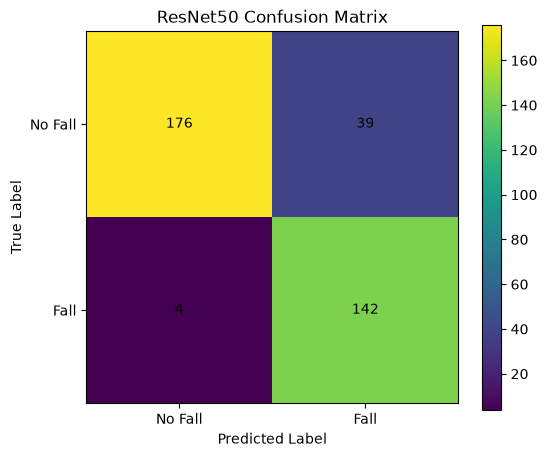

In [34]:
plt.figure(figsize=(6, 5))

plt.imshow(resnet_cm)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["No Fall", "Fall"])
plt.yticks([0, 1], ["No Fall", "Fall"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            resnet_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

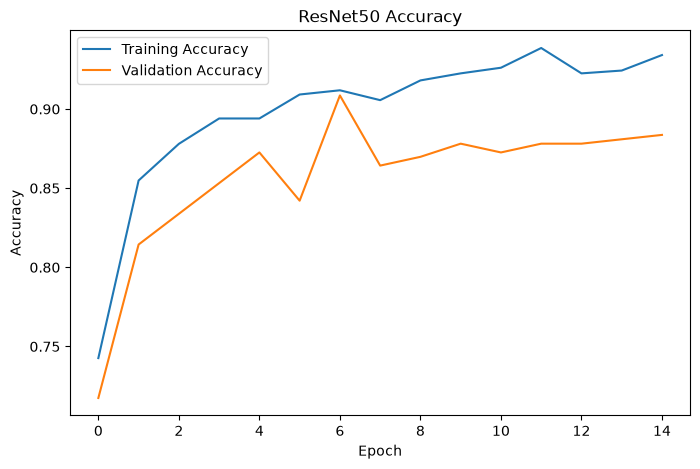

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    resnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.show()

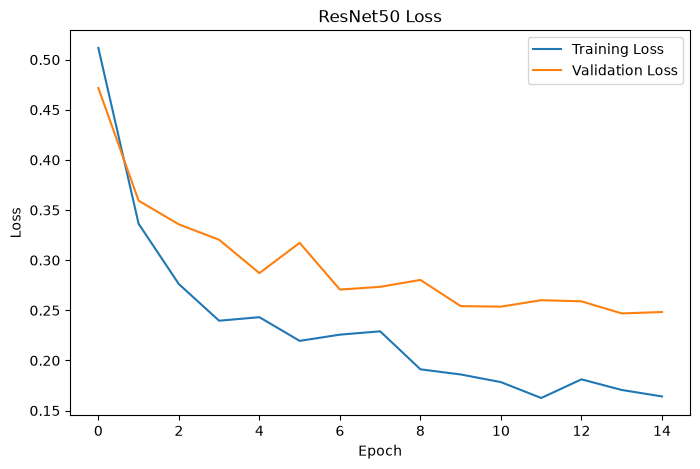

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    resnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.show()

In [37]:
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(exist_ok=True)

print("Results folder:", RESULTS_DIR)

Results folder: C:\Users\GArvit\Desktop\Fall Detection\results


In [38]:
from sklearn.metrics import classification_report

resnet_report = classification_report(
    true_labels,
    resnet_predicted_labels,
    target_names=["No Fall", "Fall"],
    digits=4
)

print(resnet_report)

              precision    recall  f1-score   support

     No Fall     0.9778    0.8186    0.8911       215
        Fall     0.7845    0.9726    0.8685       146

    accuracy                         0.8809       361
   macro avg     0.8812    0.8956    0.8798       361
weighted avg     0.8996    0.8809    0.8820       361



In [39]:
with open(
    RESULTS_DIR / "resnet50_metrics.txt",
    "w"
) as file:
    file.write("RESNET50 CLASSIFICATION REPORT\n")
    file.write("=" * 40 + "\n\n")
    file.write(resnet_report)

print("Saved resnet50_metrics.txt")

Saved resnet50_metrics.txt


In [40]:
with open(
    RESULTS_DIR / "resnet50_metrics.txt",
    "a"
) as file:
    file.write("\n\nRESNET50 CONFUSION MATRIX\n")
    file.write("=" * 40 + "\n")
    file.write(str(resnet_cm))

print("Confusion matrix values added")

Confusion matrix values added


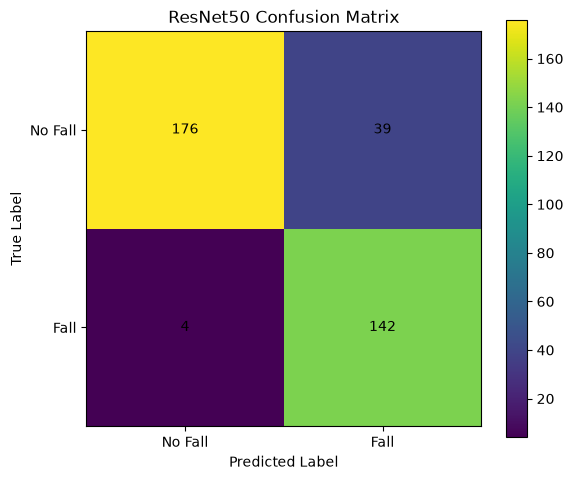

Saved confusion matrix image


In [41]:
plt.figure(figsize=(6, 5))

plt.imshow(resnet_cm)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["No Fall", "Fall"])
plt.yticks([0, 1], ["No Fall", "Fall"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            resnet_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved confusion matrix image")

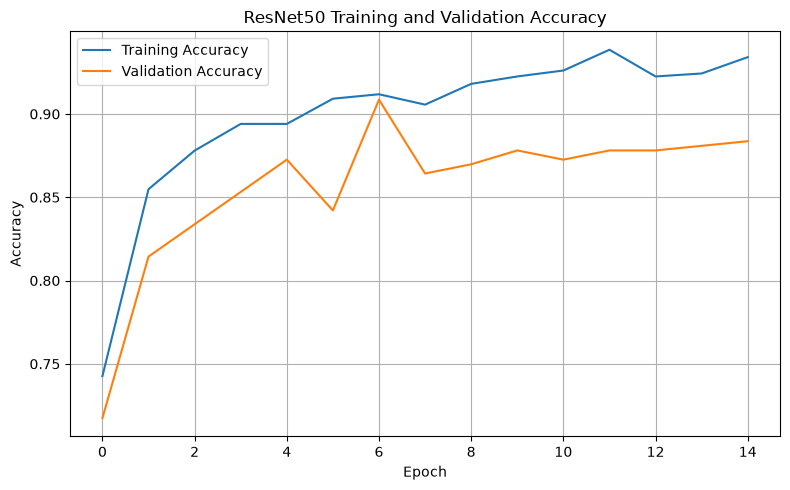

Saved accuracy curve


In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    resnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "resnet50_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved accuracy curve")

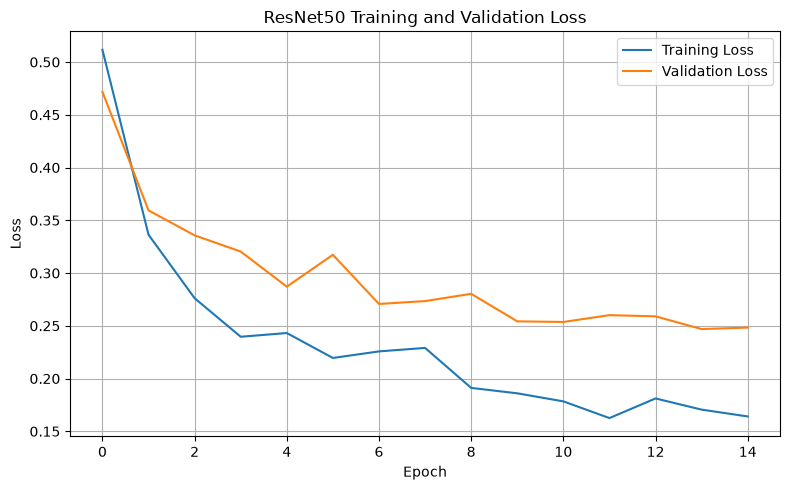

Saved loss curve


In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    resnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "resnet50_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved loss curve")